In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv(r"student_dataset/student_failure/train.csv")



print(df.shape)     # nombre de lignes / colonnes
print(df.columns)   # noms des colonnes
df.head()


(630000, 15)
Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='str')


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


# Structure du dataset

In [46]:
# Types et valeurs non-nulles par colonne
print("=== df.info() ===")
df.info()


=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        630000 non-null  int64  
 1   age                       630000 non-null  int64  
 2   genre                     630000 non-null  str    
 3   diplôme                   630000 non-null  str    
 4   heures_etude              611100 non-null  float64
 5   assiduité_classe          630000 non-null  float64
 6   accès_internet            567000 non-null  str    
 7   heures_sommeil            630000 non-null  float64
 8   qualité_sommeil           630000 non-null  str    
 9   méthode_etude             585900 non-null  str    
 10  évaluation_établissement  630000 non-null  str    
 11  difficulté_examen         630000 non-null  str    
 12  score_examen              630000 non-null  float64
 13  heures_fête               630000 non-

In [47]:
# Statistiques descriptives
print("=== df.describe() ===")
df.describe()


=== df.describe() ===


,id,age,heures_etude,assiduité_classe,heures_sommeil,score_examen,heures_fête,taille_etudiant
count,630000.000000,630000.000000,611100.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002779,71.987261,7.072758,63.406789,4.000514,1.754836
std,181865.479132,2.260238,2.359388,17.430098,1.744811,18.950840,2.000382,0.131891
min,0.000000,17.000000,0.080000,40.600000,4.100000,12.600000,0.000000,1.480000
25%,157499.750000,19.000000,1.980000,57.000000,5.600000,49.600000,3.000000,1.660000
50%,314999.500000,21.000000,4.010000,72.600000,7.100000,63.620000,4.000000,1.750000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,77.300000,5.000000,1.850000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000,19.000000,2.030000


In [48]:
# Valeurs manquantes par colonne (nombre et pourcentage)
nan_counts = df.isnull().sum()
nan_pct = (df.isnull().sum() / len(df) * 100).round(2)

nan_df = pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct})
nan_df = nan_df[nan_df["NaN count"] > 0].sort_values("NaN %", ascending=False)

print("=== Valeurs manquantes ===")
print(nan_df if len(nan_df) > 0 else "Aucune valeur manquante")


=== Valeurs manquantes ===
                NaN count  NaN %
accès_internet      63000   10.0
méthode_etude       44100    7.0
heures_etude        18900    3.0


# nettoyage des données


In [49]:
def categorize(score):
    if score < 50:
        return "fail"
    elif score <= 60:
        return "risk"
    else:
        return "pass"

df["target"] = df["score_examen"].apply(categorize)
df["target"].value_counts()

target
pass    358085
fail    161083
risk    110832
Name: count, dtype: int64

# EDA

In [50]:
ids = df["id"]

df = df.drop(columns=["id"])
X = df.drop(columns=["score_examen", "target"])
y = df["target"]

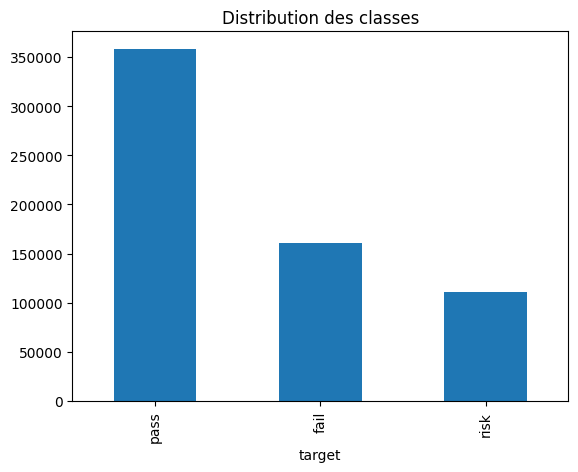

In [51]:
#distribution des classes
df["target"].value_counts().plot(kind="bar")
plt.title("Distribution des classes")
plt.show()

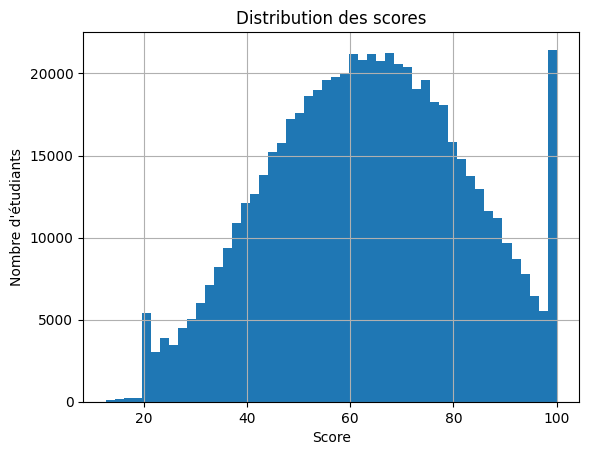

In [52]:
#distribution des notes

df["score_examen"].hist(bins=50)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre d'étudiants")
plt.show()

# Distribution des variables numériques

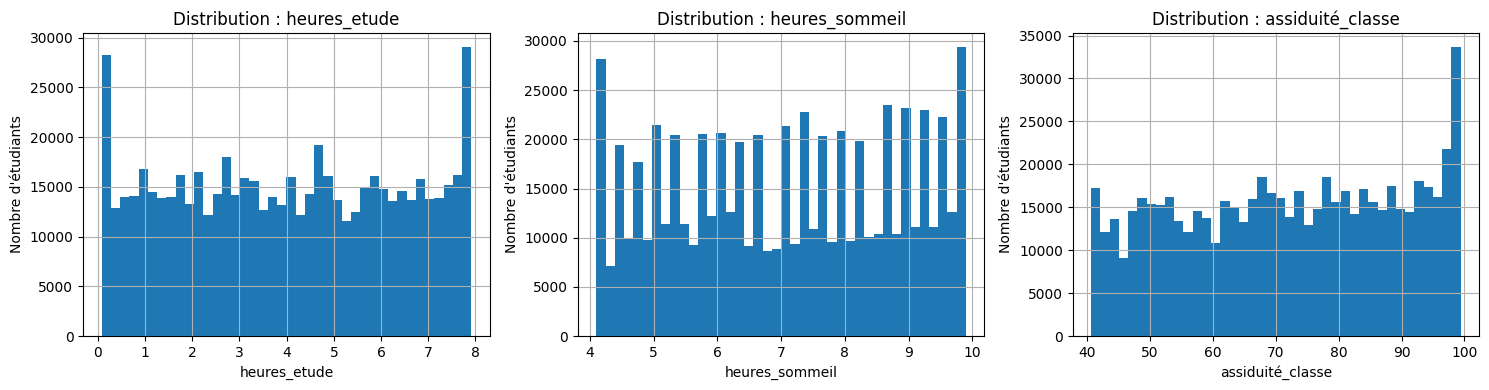

In [53]:
# Histogrammes des variables numériques principales
num_features = ["heures_etude", "heures_sommeil", "assiduité_classe"]

fig, axes = plt.subplots(1, len(num_features), figsize=(15, 4))

for ax, col in zip(axes, num_features):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(f"Distribution : {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.show()


# Distribution des variables catégorielles

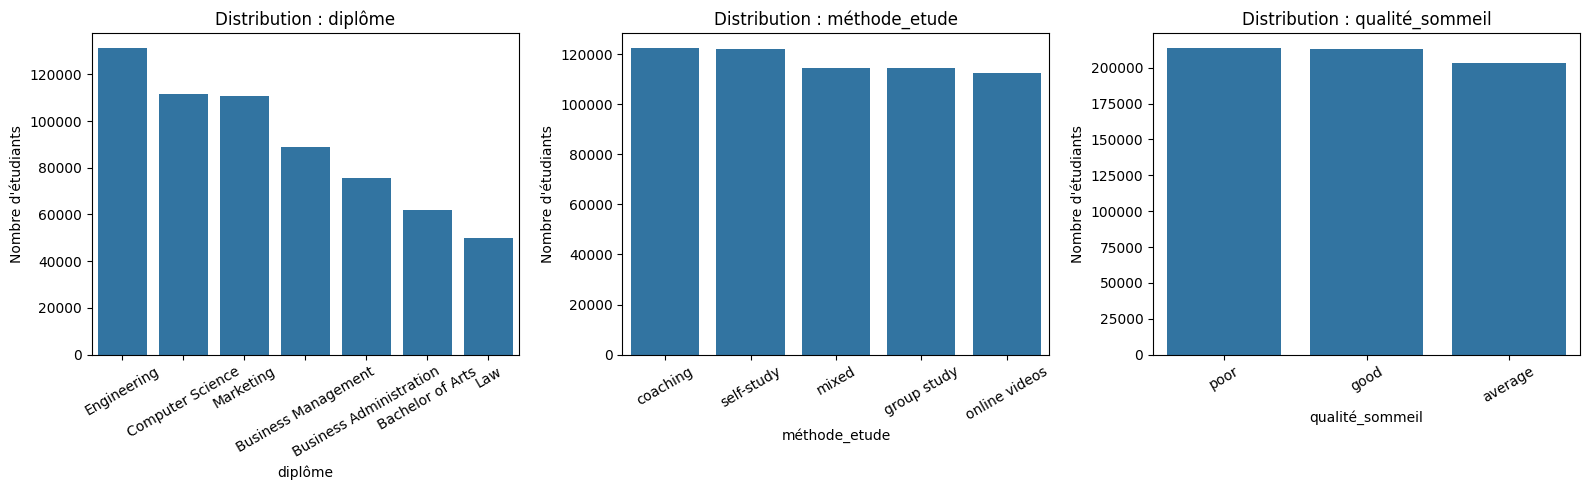

In [54]:
# Count plots des variables catégorielles
cat_features = ["diplôme", "méthode_etude", "qualité_sommeil"]

fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 5))

for ax, col in zip(axes, cat_features):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=ax)
    ax.set_title(f"Distribution : {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre d'étudiants")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


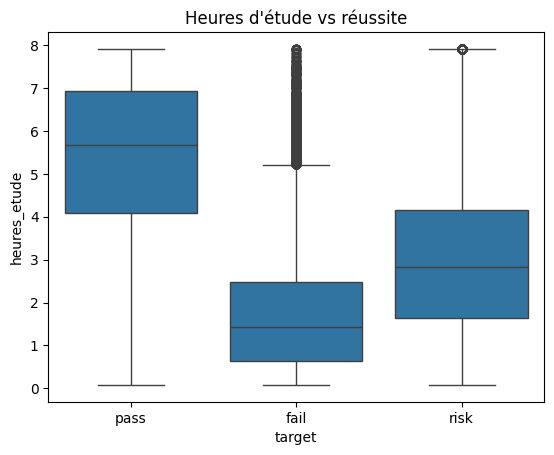

In [55]:
import seaborn as sns

sns.boxplot(x="target", y="heures_etude", data=df)
plt.title("Heures d'étude vs réussite")
plt.show()

on peut voir que le nombre etude est fortement correllé a la reussite scolaire. Cependant on peut aussi observer que certains eleves ont très peu etudié voir pas et on quand meme reussi. Le nombre heure etude suel ne suffit pas a explqiuer la reussite

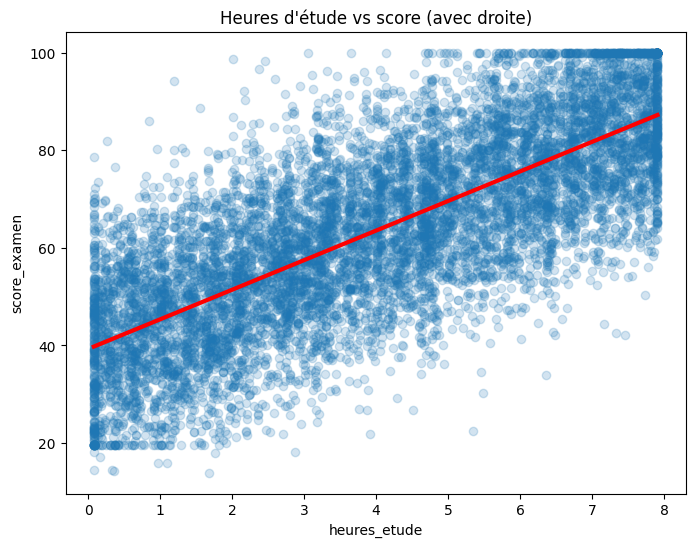

0.7576477087851184


In [56]:

sample = df.sample(10000)

plt.figure(figsize=(8,6))

sns.regplot(
    x="heures_etude",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)

plt.title("Heures d'étude vs score (avec droite)")
plt.show()

print(df["heures_etude"].corr(df["score_examen"]))

# Assiduité en classe vs réussite

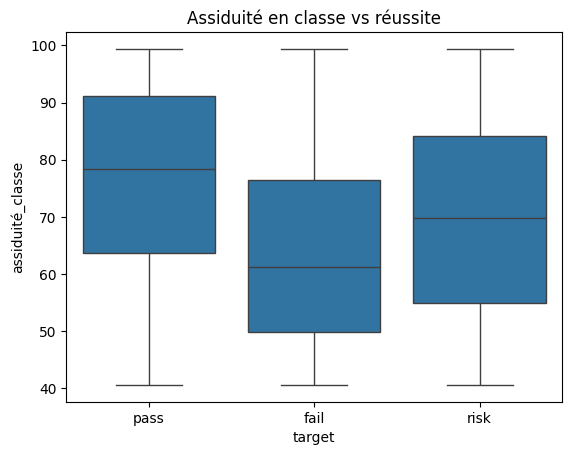

In [57]:
# Boxplot : assiduité_classe vs target
sns.boxplot(x="target", y="assiduité_classe", data=df)
plt.title("Assiduité en classe vs réussite")
plt.show()


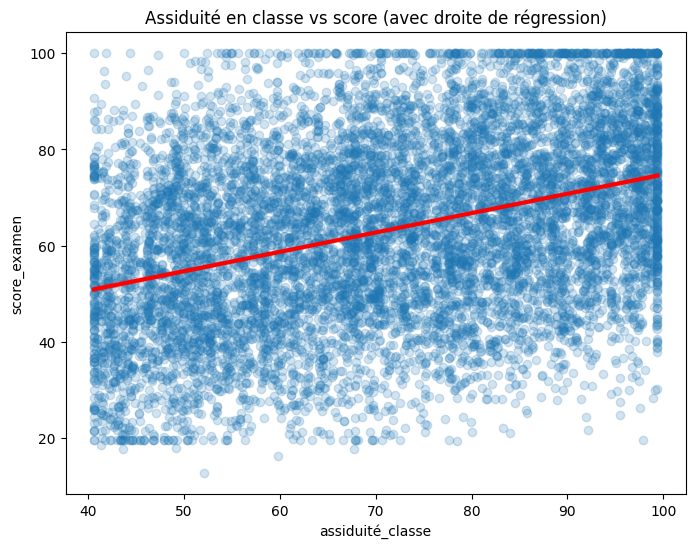

0.35945169608239697


In [58]:
# Regplot : assiduité_classe vs score_examen
sample = df.sample(10000)

plt.figure(figsize=(8, 6))
sns.regplot(
    x="assiduité_classe",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)
plt.title("Assiduité en classe vs score (avec droite de régression)")
plt.show()

print(df["assiduité_classe"].corr(df["score_examen"]))


# Genre vs réussite

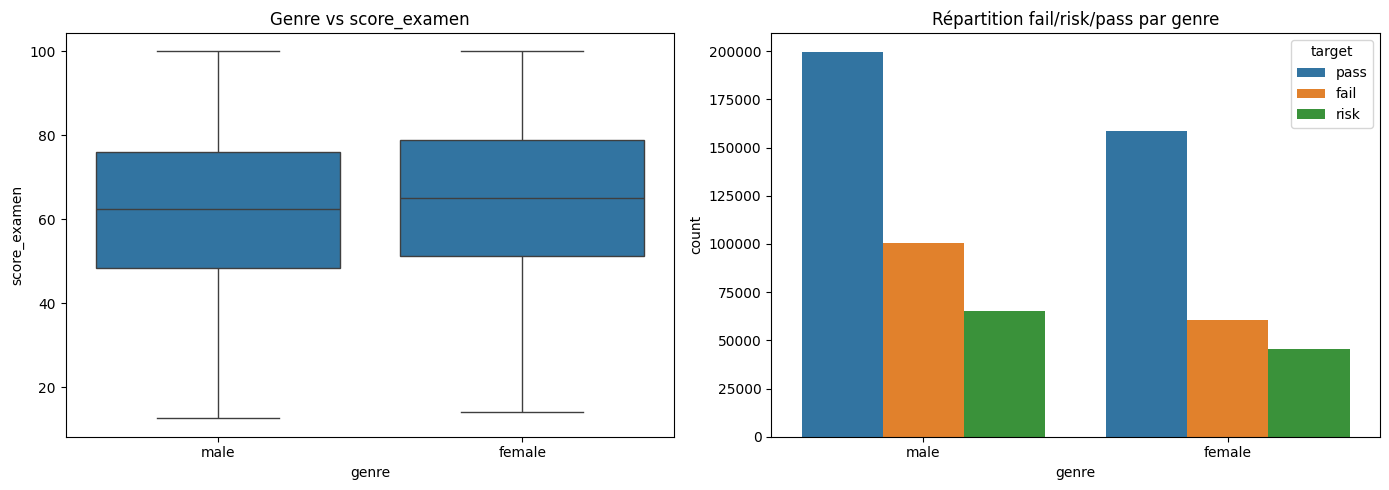

genre
female    65.036548
male      62.228632
Name: score_examen, dtype: float64


In [59]:
# Distribution des classes (fail/risk/pass) par genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot : genre vs score_examen
sns.boxplot(x="genre", y="score_examen", data=df, ax=axes[0])
axes[0].set_title("Genre vs score_examen")

# Countplot : répartition des classes par genre
sns.countplot(x="genre", hue="target", data=df, ax=axes[1])
axes[1].set_title("Répartition fail/risk/pass par genre")

plt.tight_layout()
plt.show()

print(df.groupby("genre")["score_examen"].mean())


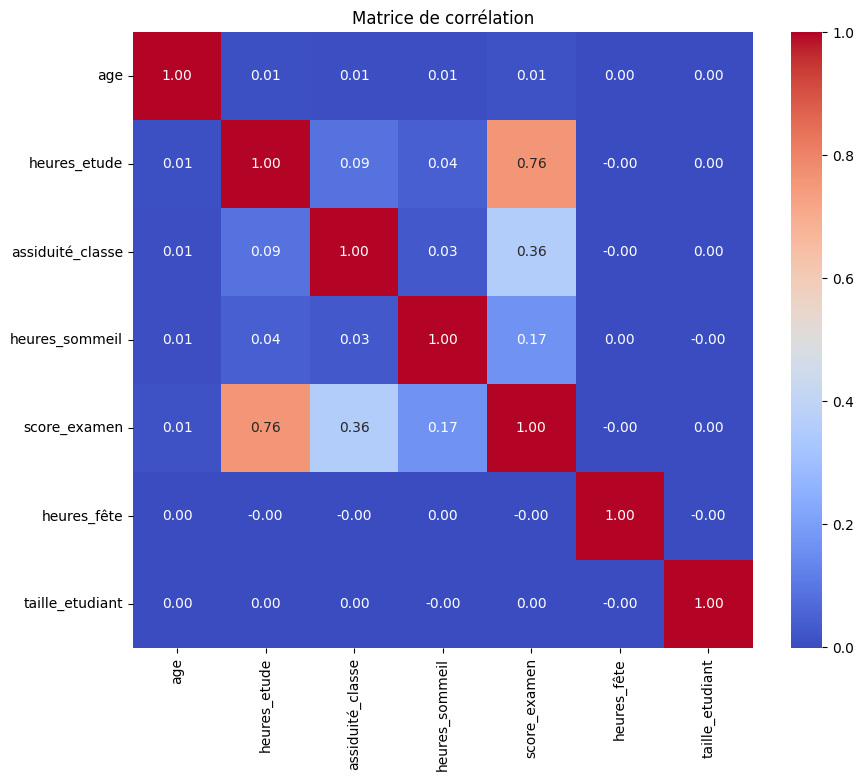

In [60]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD
# -------------------------
df = pd.read_csv(r"student_dataset/student_failure/train.csv")

# -------------------------
# 2. COPIE
# -------------------------
df_ml = df.copy()

# -------------------------
# 3. SUPPRIMER ID
# -------------------------
df_ml = df_ml.drop(columns=["id"])

# -------------------------
# 4. SUPPRESSION DES DOUBLONS
# -------------------------
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(df_ml)} (reste {len(df_ml)} lignes)")

# -------------------------
# 5. GESTION DES NaN (propre)
# -------------------------

# numérique → moyenne
num_cols = df_ml.select_dtypes(include=np.number).columns
df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())

# catégoriel → "unknown"
cat_cols = df_ml.select_dtypes(include="object").columns
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# -------------------------
# 6. ENCODING
# -------------------------

# binaire
df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)
df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# ordinal
df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
    "poor": 0,
    "average": 1,
    "good": 2,
    "excellent": 3
}).fillna(1)

df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
    "low": 0,
    "medium": 1,
    "high": 2
}).fillna(1)

df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
    "easy": 0,
    "moderate": 1,
    "hard": 2
}).fillna(1)

# nominal → one-hot
df_ml = pd.get_dummies(
    df_ml,
    columns=["diplôme", "méthode_etude"],
    drop_first=True
)

# convertir bool → float
df_ml = df_ml.astype(float)

# -------------------------
# 7. CHECK FINAL
# -------------------------
print(f"\nNaN restants : {df_ml.isna().sum().sum()}")
print(f"Shape final : {df_ml.shape}")


Doublons supprimés : 0 (reste 630000 lignes)


C:\Users\felix\AppData\Local\Temp\ipykernel_61336\1949567864.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include="object").columns



NaN restants : 0
Shape final : (630000, 23)


In [62]:
from sklearn.feature_selection import mutual_info_regression

X = df_ml.drop(columns=["score_examen"])
y = df_ml["score_examen"]

mi = mutual_info_regression(X, y)

mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi.head(15))

heures_etude                   0.641966
genre                          0.384588
assiduité_classe               0.182344
heures_sommeil                 0.042984
qualité_sommeil                0.032482
évaluation_établissement       0.024324
accès_internet                 0.021562
diplôme_Engineering            0.019039
méthode_etude_self-study       0.011416
diplôme_Computer Science       0.010592
diplôme_Marketing              0.010295
age                            0.005758
méthode_etude_group study      0.005640
méthode_etude_online videos    0.004937
difficulté_examen              0.004258
dtype: float64


In [63]:
from sklearn.feature_selection import mutual_info_regression

mi_sleep = mutual_info_regression(
    df_ml[["heures_sommeil"]],
    df_ml["qualité_sommeil"]
)

print(mi_sleep)

#df_ml["sleep_interaction"] = df_ml["heures_sommeil"] * df_ml["qualité_sommeil"]
#mi = mutual_info_regression(X, y)
#print(mi)

[0.00261384]


# heatmap utile 

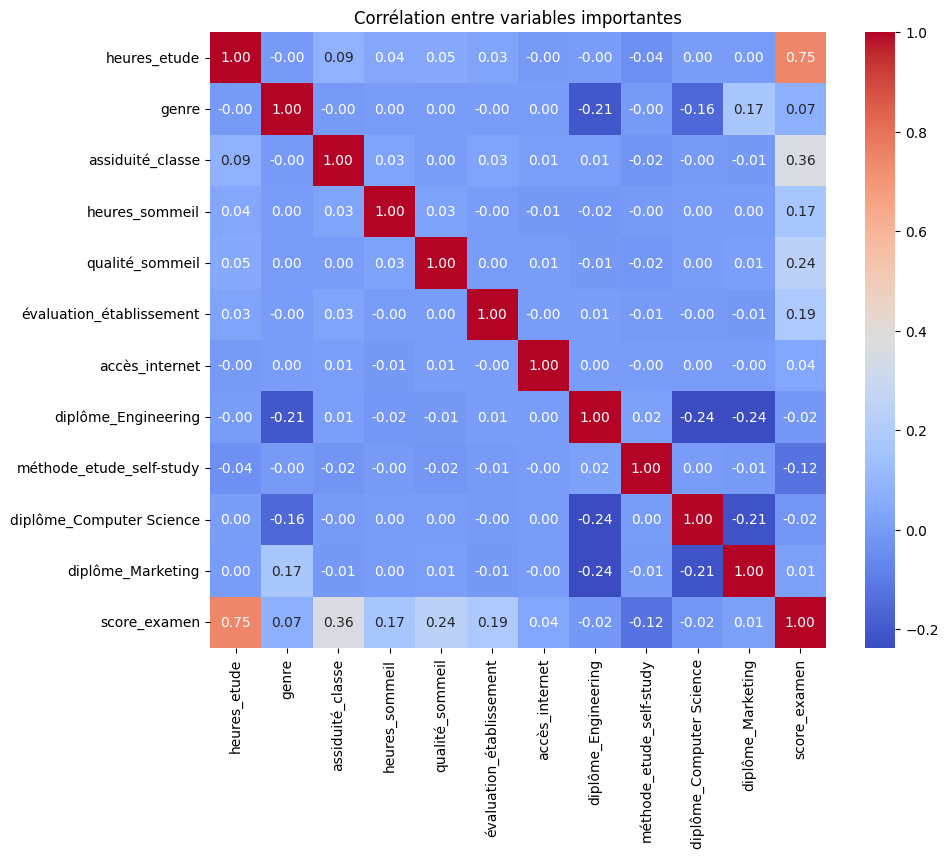

In [64]:
mi = pd.Series(mi, index=X.columns).sort_values(ascending=False)

important_features = mi[mi > 0.01].index.tolist()

# ajouter la target
important_features.append("score_examen")

corr = df_ml[important_features].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Corrélation entre variables importantes")
plt.show()